<a href="https://colab.research.google.com/github/Charan0622/Recommender-system-for-Beers-Dataset/blob/main/Beer_Recommender_Phase1_ItemCF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beer Recommender — Phase 1: Item-Based Collaborative Filtering

This notebook implements **Item-Based Collaborative Filtering** as a baseline model.

**Approach:** Predict a user's rating for an item by looking at items the user has already rated, weighting those ratings by how *similar* the target item is to each rated item (cosine similarity on the user-item rating matrix).

**Pipeline:**
1. Load & preprocess both BeerAdvocate + RateBeer datasets (shared with EDA & MF notebooks)
2. Per-user chronological 80/10/10 train/val/test split
3. Build item-item cosine similarity matrix from training data
4. Predict ratings using KNN-style weighted average of similar items
5. Evaluate with RMSE, MAE and compare against popularity & user+item bias baselines
6. Top-N ranking evaluation (Precision@K, Recall@K, NDCG@K)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup & Imports

In [6]:
import ast
import gzip
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore')

print('All imports successful.')

All imports successful.


In [7]:
# ── Path configuration ─────────────────────────────────────────────────
# Toggle this flag when running on Google Colab with Drive mounted
USE_COLAB_DRIVE = False

if USE_COLAB_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks')
else:
    DATA_DIR = Path('.')

BA_PATH = DATA_DIR / '/content/drive/MyDrive/Colab Notebooks/beeradvocate.json.gz'
RB_PATH = DATA_DIR / '/content/drive/MyDrive/Colab Notebooks/ratebeer.json.gz'

print(f'Data directory: {DATA_DIR}')
print(f'BeerAdvocate exists: {BA_PATH.exists()}')
print(f'RateBeer exists:     {RB_PATH.exists()}')

Data directory: .
BeerAdvocate exists: True
RateBeer exists:     True


## 2. Data Loading

In [8]:
def load_dict_per_line(filepath):
    """Load a .json.gz or .json file where each line is a Python dict literal."""
    records = []
    opener = gzip.open if str(filepath).endswith('.gz') else open
    with opener(filepath, 'rt', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(ast.literal_eval(line))
    return pd.DataFrame(records)

t0 = time.time()
beer_advocate = load_dict_per_line(BA_PATH)
print(f'BeerAdvocate loaded: {beer_advocate.shape}  ({time.time()-t0:.1f}s)')

t0 = time.time()
rate_beer = load_dict_per_line(RB_PATH)
print(f'RateBeer loaded:     {rate_beer.shape}  ({time.time()-t0:.1f}s)')

BeerAdvocate loaded: (1586615, 13)  (47.0s)
RateBeer loaded:     (2924164, 13)  (76.5s)


## 3. Preprocessing (shared pipeline)

In [9]:
# ── Parse ratings: handles both "3.5" and "13/20" formats ──────────────
def parse_rating(val):
    try:
        s = str(val)
        if '/' in s:
            num, denom = s.split('/')
            return float(num) / float(denom)
        return float(s)
    except (ValueError, TypeError):
        return np.nan

rating_cols = ['review/appearance', 'review/aroma', 'review/palate',
               'review/taste', 'review/overall']

for col in rating_cols:
    beer_advocate[col] = beer_advocate[col].apply(parse_rating)
    rate_beer[col]     = rate_beer[col].apply(parse_rating)

# ── Normalise BeerAdvocate (0-5) → (0-1) ──────────────────────────────
beer_advocate[rating_cols] = beer_advocate[rating_cols] / 5.0

# ── ABV → float ───────────────────────────────────────────────────────
for df_ in (beer_advocate, rate_beer):
    df_['beer/ABV'] = pd.to_numeric(df_['beer/ABV'], errors='coerce')
    df_['review/time'] = pd.to_numeric(df_['review/time'], errors='coerce')

# ── Tag source & combine ──────────────────────────────────────────────
beer_advocate['source'] = 'beeradvocate'
rate_beer['source']     = 'ratebeer'

df = pd.concat([beer_advocate, rate_beer], axis=0, ignore_index=True)

# ── Unique item IDs (source-scoped) ───────────────────────────────────
df['item_id'] = df['source'] + '_' + df['beer/beerId'].astype(str)

# ── Drop missing core data & duplicates ───────────────────────────────
core_cols_check = ['review/profileName', 'item_id', 'review/overall']
before = len(df)
df = df.dropna(subset=core_cols_check).copy()
df = df.drop_duplicates(subset=['review/profileName', 'item_id'], keep='first').copy()
print(f'Rows dropped: {before - len(df):,}  |  Rows remaining: {len(df):,}')

# ── K-core filtering (min 5 reviews per user & item) ─────────────────
MIN_USER_REVIEWS = 5
MIN_ITEM_REVIEWS = 5

for iteration in range(3):
    user_counts = df['review/profileName'].value_counts()
    item_counts = df['item_id'].value_counts()
    df = df[df['review/profileName'].isin(user_counts[user_counts >= MIN_USER_REVIEWS].index)]
    df = df[df['item_id'].isin(item_counts[item_counts >= MIN_ITEM_REVIEWS].index)]

df = df.reset_index(drop=True)

print(f'\nAfter k-core filtering:')
print(f'  Users: {df["review/profileName"].nunique():,}')
print(f'  Items: {df["item_id"].nunique():,}')
print(f'  Interactions: {len(df):,}')

# ── Sanity check rating range ─────────────────────────────────────────
print(f'\nRating range: [{df["review/overall"].min():.3f}, {df["review/overall"].max():.3f}]')
print(f'Mean rating:  {df["review/overall"].mean():.4f}')

Rows dropped: 83,739  |  Rows remaining: 4,427,040

After k-core filtering:
  Users: 26,540
  Items: 75,476
  Interactions: 4,176,991

Rating range: [0.000, 1.000]
Mean rating:  0.6979


## 4. Temporal Train / Val / Test Split

In [10]:
# ── Per-user chronological 80/10/10 split ─────────────────────────────
df_sorted = df.sort_values(['review/profileName', 'review/time']).reset_index(drop=True)

train_parts, val_parts, test_parts = [], [], []
MIN_USER_INTERACTIONS = 5

for _, g in df_sorted.groupby('review/profileName', sort=False):
    n = len(g)
    if n < MIN_USER_INTERACTIONS:
        train_parts.append(g)
        continue

    n_test  = max(1, int(round(0.1 * n)))
    n_val   = max(1, int(round(0.1 * n)))
    n_train = n - n_val - n_test

    if n_train < 1:
        n_train, n_val, n_test = n - 2, 1, 1

    train_parts.append(g.iloc[:n_train])
    val_parts.append(g.iloc[n_train:n_train + n_val])
    test_parts.append(g.iloc[n_train + n_val:])

train_df = pd.concat(train_parts, ignore_index=True)
val_df   = pd.concat(val_parts,   ignore_index=True)
test_df  = pd.concat(test_parts,  ignore_index=True)

print(f'Train: {len(train_df):,} ({len(train_df)/len(df):.1%})')
print(f'Val:   {len(val_df):,} ({len(val_df)/len(df):.1%})')
print(f'Test:  {len(test_df):,} ({len(test_df)/len(df):.1%})')

Train: 3,336,965 (79.9%)
Val:   420,013 (10.1%)
Test:  420,013 (10.1%)


In [11]:
# ── Build index mappings from TRAIN ONLY ──────────────────────────────
train_users = sorted(train_df['review/profileName'].unique())
train_items = sorted(train_df['item_id'].unique())

user2idx = {u: i for i, u in enumerate(train_users)}
item2idx = {it: i for i, it in enumerate(train_items)}
idx2item = {i: it for it, i in item2idx.items()}

n_users = len(user2idx)
n_items = len(item2idx)

# ── Filter val/test to seen users & items only ────────────────────────
val_df = val_df[
    val_df['review/profileName'].isin(user2idx) &
    val_df['item_id'].isin(item2idx)
].copy()

test_df = test_df[
    test_df['review/profileName'].isin(user2idx) &
    test_df['item_id'].isin(item2idx)
].copy()

# ── Map to integer indices ────────────────────────────────────────────
for part in [train_df, val_df, test_df]:
    part['user_idx'] = part['review/profileName'].map(user2idx)
    part['item_idx'] = part['item_id'].map(item2idx)

print(f'n_users: {n_users:,}')
print(f'n_items: {n_items:,}')
print(f'Val rows (after filter):  {len(val_df):,}')
print(f'Test rows (after filter): {len(test_df):,}')

n_users: 26,540
n_items: 73,977
Val rows (after filter):  417,856
Test rows (after filter): 410,885


## 5. Build User-Item Sparse Matrix

In [12]:
# ── Sparse user-item rating matrix from training data ─────────────────
# Shape: (n_users, n_items) — each cell holds the rating (0-1) or 0 if unrated

t0 = time.time()
train_user_idxs = train_df['user_idx'].values
train_item_idxs = train_df['item_idx'].values
train_ratings   = train_df['review/overall'].values.astype(np.float32)

R_train = csr_matrix(
    (train_ratings, (train_user_idxs, train_item_idxs)),
    shape=(n_users, n_items)
)

print(f'User-item matrix: {R_train.shape}')
print(f'Non-zero entries: {R_train.nnz:,}')
print(f'Sparsity: {1 - R_train.nnz / (R_train.shape[0] * R_train.shape[1]):.4%}')
print(f'Built in {time.time()-t0:.2f}s')

User-item matrix: (26540, 73977)
Non-zero entries: 3,336,965
Sparsity: 99.8300%
Built in 0.12s


## 6. Item-Item Cosine Similarity

We compute cosine similarity between item vectors (columns of the user-item matrix).
To keep memory manageable, we compute in blocks and only store the **top-K** most similar items per item.

In [13]:
# ── Configuration ─────────────────────────────────────────────────────
K_NEIGHBORS = 50          # Number of similar items to store per item
BLOCK_SIZE  = 2000        # Process items in blocks to control memory
MIN_COMMON_USERS = 3     # Minimum co-rated users for a valid similarity

print(f'K_NEIGHBORS:      {K_NEIGHBORS}')
print(f'BLOCK_SIZE:       {BLOCK_SIZE}')
print(f'MIN_COMMON_USERS: {MIN_COMMON_USERS}')

K_NEIGHBORS:      50
BLOCK_SIZE:       2000
MIN_COMMON_USERS: 3


In [14]:
# ── Compute item-item similarity in blocks ────────────────────────────
# R_train.T gives us an (n_items, n_users) matrix — each row is an item
# vector in user-space. Cosine similarity between item rows tells us
# which items are rated similarly by the same users.

R_item = R_train.T.tocsr()  # (n_items, n_users)

# Binary version for counting co-rated users
R_binary = (R_train > 0).astype(np.float32).T.tocsr()  # (n_items, n_users)

# Storage: for each item, store top-K neighbor indices and their similarities
sim_indices = np.zeros((n_items, K_NEIGHBORS), dtype=np.int32)
sim_values  = np.zeros((n_items, K_NEIGHBORS), dtype=np.float32)

t0 = time.time()
n_blocks = (n_items + BLOCK_SIZE - 1) // BLOCK_SIZE

for block_idx in range(n_blocks):
    start = block_idx * BLOCK_SIZE
    end   = min(start + BLOCK_SIZE, n_items)

    # Cosine similarity of this block against ALL items: (block_size, n_items)
    block_sim = cosine_similarity(R_item[start:end], R_item)

    # Count co-rated users for items in this block vs all items
    block_corated = (R_binary[start:end] @ R_binary.T).toarray()

    # Zero out similarities where co-rated users < threshold
    block_sim[block_corated < MIN_COMMON_USERS] = 0.0

    for local_i in range(end - start):
        global_i = start + local_i
        sims = block_sim[local_i]
        sims[global_i] = 0.0  # exclude self-similarity

        # Get top-K neighbors
        if K_NEIGHBORS < len(sims):
            top_k_idx = np.argpartition(sims, -K_NEIGHBORS)[-K_NEIGHBORS:]
        else:
            top_k_idx = np.arange(len(sims))

        # Sort by similarity descending
        top_k_idx = top_k_idx[np.argsort(sims[top_k_idx])[::-1]]
        k_actual = min(K_NEIGHBORS, len(top_k_idx))

        sim_indices[global_i, :k_actual] = top_k_idx[:k_actual]
        sim_values[global_i, :k_actual]  = sims[top_k_idx[:k_actual]]

    elapsed = time.time() - t0
    if (block_idx + 1) % 5 == 0 or block_idx == n_blocks - 1:
        print(f'  Block {block_idx+1}/{n_blocks} done  ({elapsed:.1f}s elapsed)')

print(f'\nItem-item similarity computed in {time.time()-t0:.1f}s')
print(f'Avg non-zero neighbors per item: {(sim_values > 0).sum(axis=1).mean():.1f}')

  Block 5/37 done  (22.1s elapsed)
  Block 10/37 done  (41.3s elapsed)
  Block 15/37 done  (64.4s elapsed)
  Block 20/37 done  (83.8s elapsed)
  Block 25/37 done  (111.0s elapsed)
  Block 30/37 done  (138.3s elapsed)
  Block 35/37 done  (165.2s elapsed)
  Block 37/37 done  (175.6s elapsed)

Item-item similarity computed in 175.6s
Avg non-zero neighbors per item: 46.1


## 7. Item-Based CF Prediction

For a (user, item) pair, the predicted rating is:

$$\hat{r}_{u,i} = \frac{\sum_{j \in N(i) \cap I_u} s_{i,j} \cdot r_{u,j}}{\sum_{j \in N(i) \cap I_u} |s_{i,j}|}$$

Where $N(i)$ is the set of top-K neighbors of item $i$, $I_u$ is items rated by user $u$, and $s_{i,j}$ is the cosine similarity.

In [15]:
# ── Precompute per-user rated items for fast lookup ───────────────────
# Dictionary: user_idx → dict of {item_idx: rating}

t0 = time.time()
user_rated_items = {}
for u_idx, i_idx, rating in zip(train_user_idxs, train_item_idxs, train_ratings):
    if u_idx not in user_rated_items:
        user_rated_items[u_idx] = {}
    user_rated_items[u_idx][i_idx] = rating

print(f'User lookup built in {time.time()-t0:.2f}s')
print(f'Users with ratings: {len(user_rated_items):,}')

User lookup built in 0.62s
Users with ratings: 26,540


In [16]:
# ── Global mean (fallback for cold cases) ─────────────────────────────
global_mean = float(train_df['review/overall'].mean())
print(f'Global mean: {global_mean:.4f}')

Global mean: 0.6956


In [17]:
def itemcf_predict(user_idxs, item_idxs):
    """
    Predict ratings for arrays of (user_idx, item_idx) pairs
    using item-based collaborative filtering.
    """
    preds = np.full(len(user_idxs), global_mean, dtype=np.float32)

    for idx in range(len(user_idxs)):
        u = user_idxs[idx]
        i = item_idxs[idx]

        u_ratings = user_rated_items.get(u, {})
        if not u_ratings:
            continue

        # Get neighbors of item i
        neighbors = sim_indices[i]
        sims      = sim_values[i]

        numerator   = 0.0
        denominator = 0.0

        for k in range(K_NEIGHBORS):
            neighbor_item = neighbors[k]
            sim = sims[k]

            if sim <= 0:
                break  # remaining neighbors have 0 similarity

            if neighbor_item in u_ratings:
                numerator   += sim * u_ratings[neighbor_item]
                denominator += abs(sim)

        if denominator > 0:
            preds[idx] = numerator / denominator

    return np.clip(preds, 0.0, 1.0)

print('Prediction function ready.')

Prediction function ready.


In [18]:
# ── Quick sanity check on a small sample ──────────────────────────────
sample = train_df.head(5)
sample_preds = itemcf_predict(sample['user_idx'].values, sample['item_idx'].values)
for _, row in sample.iterrows():
    print(f"User={row['review/profileName'][:20]:<20s}  "
          f"Item={row['item_id'][:30]:<30s}  "
          f"Actual={row['review/overall']:.3f}")
print(f'Predictions: {sample_preds}')

User=                      Item=beeradvocate_5583               Actual=0.800
User=                      Item=beeradvocate_1443               Actual=0.900
User=                      Item=beeradvocate_2178               Actual=0.900
User=                      Item=beeradvocate_722                Actual=0.900
User=                      Item=beeradvocate_2422               Actual=1.000
Predictions: [0.4        0.7643969  0.8391258  0.81846493 0.8       ]


## 8. Vectorized Prediction (faster for large evaluation sets)

The pure-Python loop above is correct but slow on large datasets. Here we batch the predictions.

In [19]:
def itemcf_predict_batched(df_eval, batch_size=50000):
    """
    Predict ratings for an evaluation DataFrame with progress reporting.
    """
    user_idxs = df_eval['user_idx'].values
    item_idxs = df_eval['item_idx'].values

    all_preds = []
    n_batches = (len(df_eval) + batch_size - 1) // batch_size
    t0 = time.time()

    for b in range(n_batches):
        start = b * batch_size
        end   = min(start + batch_size, len(df_eval))

        batch_preds = itemcf_predict(user_idxs[start:end], item_idxs[start:end])
        all_preds.append(batch_preds)

        if (b + 1) % 5 == 0 or b == n_batches - 1:
            elapsed = time.time() - t0
            print(f'  Batch {b+1}/{n_batches}  ({elapsed:.1f}s)')

    return np.concatenate(all_preds)

print('Batched prediction function ready.')

Batched prediction function ready.


## 9. Evaluation Metrics

In [20]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def eval_rating(name, y_true, y_pred):
    return {'Model': name, 'RMSE': rmse(y_true, y_pred), 'MAE': mae(y_true, y_pred)}

print('Metric functions ready.')

Metric functions ready.


## 10. Baseline Models (for comparison)

In [21]:
# ── Baseline 1: Popularity (Bayesian average) ─────────────────────────
C = global_mean
m = 25  # smoothing parameter

item_stats = (
    train_df.groupby('item_id')['review/overall']
    .agg(count='count', mean='mean')
    .assign(score=lambda x: (x['count'] * x['mean'] + m * C) / (x['count'] + m))
)
item_score_lookup = item_stats['score'].to_dict()

def pop_pred(df_eval):
    return df_eval['item_id'].map(item_score_lookup).fillna(C).values

# ── Baseline 2: User + Item Bias ──────────────────────────────────────
user_mean = train_df.groupby('review/profileName')['review/overall'].mean()
item_mean = train_df.groupby('item_id')['review/overall'].mean()

user_bias_dict = (user_mean - global_mean).to_dict()
item_bias_dict = (item_mean - global_mean).to_dict()

def bias_pred(df_eval):
    preds = np.array([
        global_mean + user_bias_dict.get(row['review/profileName'], 0.0)
                    + item_bias_dict.get(row['item_id'], 0.0)
        for _, row in df_eval.iterrows()
    ])
    return np.clip(preds, 0.0, 1.0)

print(f'Global mean: {global_mean:.4f}')
print(f'Items with popularity scores: {len(item_score_lookup):,}')
print('Baselines ready.')

Global mean: 0.6956
Items with popularity scores: 73,977
Baselines ready.


## 11. Rating Prediction Evaluation

In [22]:
# ── Predict on validation set ─────────────────────────────────────────
print('=== Validation Set ===')
print(f'Evaluating on {len(val_df):,} ratings...\n')

y_val_true = val_df['review/overall'].values

# Popularity baseline
t0 = time.time()
y_val_pop = pop_pred(val_df)
print(f'Popularity:  {time.time()-t0:.1f}s')

# User+Item Bias baseline
t0 = time.time()
y_val_bias = bias_pred(val_df)
print(f'Bias:        {time.time()-t0:.1f}s')

# Item-Based CF
t0 = time.time()
y_val_itemcf = itemcf_predict_batched(val_df)
print(f'Item-CF:     {time.time()-t0:.1f}s')

val_results = [
    eval_rating('Popularity (Bayesian)', y_val_true, y_val_pop),
    eval_rating('User+Item Bias',        y_val_true, y_val_bias),
    eval_rating('Item-Based CF (K=50)',   y_val_true, y_val_itemcf),
]

val_results_df = pd.DataFrame(val_results).set_index('Model')
print('\n--- Validation Results ---')
display(val_results_df.round(4))

=== Validation Set ===
Evaluating on 417,856 ratings...

Popularity:  0.1s
Bias:        4.5s
  Batch 5/9  (2.1s)
  Batch 9/9  (3.5s)
Item-CF:     3.5s

--- Validation Results ---


,RMSE,MAE
Model,,
Popularity (Bayesian),0.1203,0.0885
User+Item Bias,0.1283,0.0960
Item-Based CF (K=50),0.1379,0.0990


In [23]:
# ── Predict on test set ───────────────────────────────────────────────
print('=== Test Set ===')
print(f'Evaluating on {len(test_df):,} ratings...\n')

y_test_true = test_df['review/overall'].values

t0 = time.time()
y_test_pop = pop_pred(test_df)
print(f'Popularity:  {time.time()-t0:.1f}s')

t0 = time.time()
y_test_bias = bias_pred(test_df)
print(f'Bias:        {time.time()-t0:.1f}s')

t0 = time.time()
y_test_itemcf = itemcf_predict_batched(test_df)
print(f'Item-CF:     {time.time()-t0:.1f}s')

test_results = [
    eval_rating('Popularity (Bayesian)', y_test_true, y_test_pop),
    eval_rating('User+Item Bias',        y_test_true, y_test_bias),
    eval_rating('Item-Based CF (K=50)',   y_test_true, y_test_itemcf),
]

test_results_df = pd.DataFrame(test_results).set_index('Model')
print('\n--- Test Results ---')
display(test_results_df.round(4))

=== Test Set ===
Evaluating on 410,885 ratings...

Popularity:  0.1s
Bias:        4.4s
  Batch 5/9  (1.9s)
  Batch 9/9  (3.1s)
Item-CF:     3.1s

--- Test Results ---


,RMSE,MAE
Model,,
Popularity (Bayesian),0.1212,0.0892
User+Item Bias,0.1308,0.0976
Item-Based CF (K=50),0.1408,0.1018


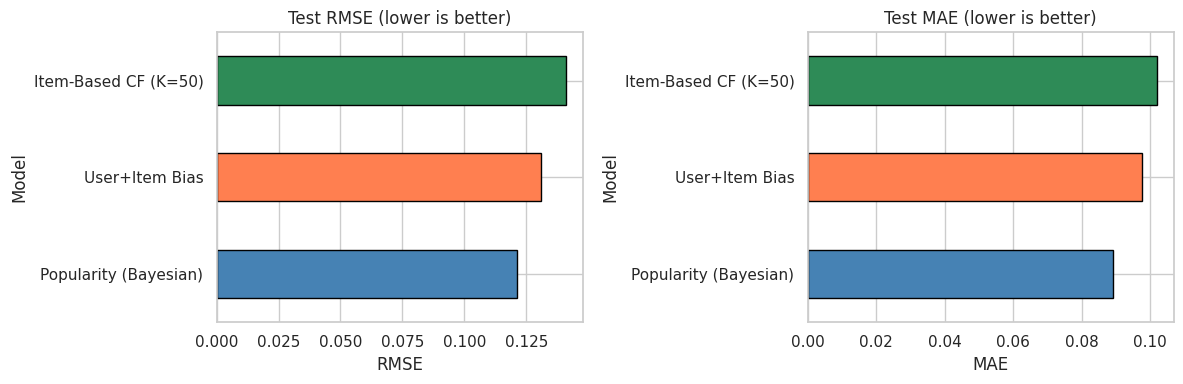

In [24]:
# ── Results comparison bar chart ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

test_results_df['RMSE'].plot(kind='barh', ax=axes[0], color=['steelblue', 'coral', 'seagreen'], edgecolor='black')
axes[0].set_title('Test RMSE (lower is better)')
axes[0].set_xlabel('RMSE')

test_results_df['MAE'].plot(kind='barh', ax=axes[1], color=['steelblue', 'coral', 'seagreen'], edgecolor='black')
axes[1].set_title('Test MAE (lower is better)')
axes[1].set_xlabel('MAE')

plt.tight_layout()
plt.show()

## 12. Hyperparameter Sensitivity: K Neighbors

In [25]:
# ── Evaluate different K values using existing similarity data ────────
# We already computed top-50 neighbors; we can simulate smaller K by
# only using the first K entries from sim_indices / sim_values.

K_values = [5, 10, 20, 30, 50]
k_results = []

# Use a sample of val set for speed
val_sample = val_df.sample(n=min(50000, len(val_df)), random_state=42)
y_val_sample_true = val_sample['review/overall'].values

for K in K_values:
    # Temporarily override K_NEIGHBORS for prediction
    orig_K = K_NEIGHBORS

    def itemcf_predict_k(user_idxs, item_idxs, k=K):
        preds = np.full(len(user_idxs), global_mean, dtype=np.float32)
        for idx in range(len(user_idxs)):
            u = user_idxs[idx]
            i = item_idxs[idx]
            u_ratings = user_rated_items.get(u, {})
            if not u_ratings:
                continue
            neighbors = sim_indices[i, :k]
            sims      = sim_values[i, :k]
            num, den = 0.0, 0.0
            for n_k in range(k):
                s = sims[n_k]
                if s <= 0:
                    break
                if neighbors[n_k] in u_ratings:
                    num += s * u_ratings[neighbors[n_k]]
                    den += abs(s)
            if den > 0:
                preds[idx] = num / den
        return np.clip(preds, 0.0, 1.0)

    t0 = time.time()
    y_pred_k = itemcf_predict_k(val_sample['user_idx'].values, val_sample['item_idx'].values)
    elapsed = time.time() - t0

    r = rmse(y_val_sample_true, y_pred_k)
    m_ = mae(y_val_sample_true, y_pred_k)
    k_results.append({'K': K, 'RMSE': r, 'MAE': m_, 'Time (s)': elapsed})
    print(f'K={K:>3d}  RMSE={r:.4f}  MAE={m_:.4f}  ({elapsed:.1f}s)')

k_results_df = pd.DataFrame(k_results).set_index('K')
display(k_results_df.round(4))

K=  5  RMSE=0.1498  MAE=0.1101  (0.1s)
K= 10  RMSE=0.1457  MAE=0.1062  (0.2s)
K= 20  RMSE=0.1420  MAE=0.1027  (0.3s)
K= 30  RMSE=0.1401  MAE=0.1010  (0.4s)
K= 50  RMSE=0.1371  MAE=0.0985  (0.6s)


,RMSE,MAE,Time (s)
K,,,
5,0.1498,0.1101,0.1034
10,0.1457,0.1062,0.1550
20,0.1420,0.1027,0.2760
30,0.1401,0.1010,0.3924
50,0.1371,0.0985,0.6161


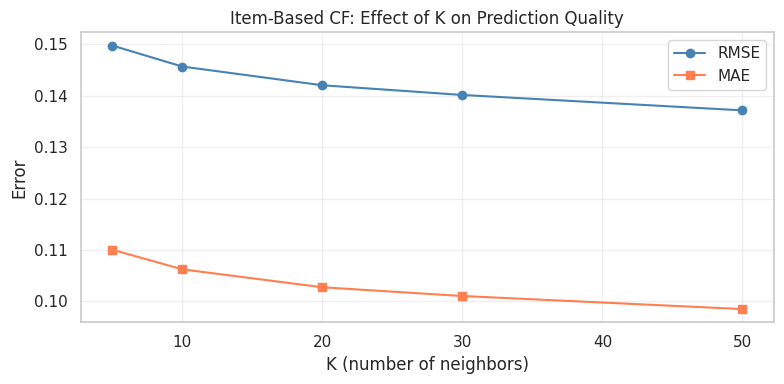

In [26]:
# ── Plot K sensitivity ────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(k_results_df.index, k_results_df['RMSE'], 'o-', color='steelblue', label='RMSE')
ax1.plot(k_results_df.index, k_results_df['MAE'],  's-', color='coral',     label='MAE')
ax1.set_xlabel('K (number of neighbors)')
ax1.set_ylabel('Error')
ax1.set_title('Item-Based CF: Effect of K on Prediction Quality')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Top-N Ranking Evaluation

In [27]:
def precision_at_k(recommended, relevant, k):
    """Fraction of top-K recommendations that are relevant."""
    rec_k = recommended[:k]
    return len(set(rec_k) & set(relevant)) / k if k > 0 else 0.0

def recall_at_k(recommended, relevant, k):
    """Fraction of relevant items that appear in top-K."""
    rec_k = recommended[:k]
    return len(set(rec_k) & set(relevant)) / len(relevant) if relevant else 0.0

def ndcg_at_k(recommended, relevant, k):
    """Normalized Discounted Cumulative Gain at K."""
    rec_k = recommended[:k]
    dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(rec_k) if item in relevant)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

print('Ranking metrics ready.')

Ranking metrics ready.


In [28]:
# ── Build test ground truth: per user, items they rated >= threshold ──
RELEVANCE_THRESHOLD = 0.7  # items rated >= 0.7 (out of 1.0) are "relevant"
TOP_K_VALUES = [5, 10, 20]

# Ground truth: relevant items in test set per user
test_relevant = (
    test_df[test_df['review/overall'] >= RELEVANCE_THRESHOLD]
    .groupby('user_idx')['item_idx']
    .apply(set)
    .to_dict()
)

# Only evaluate users who have at least 1 relevant test item
eval_users = [u for u, items in test_relevant.items() if len(items) >= 1]
print(f'Users with relevant test items: {len(eval_users):,}')
print(f'Relevance threshold: {RELEVANCE_THRESHOLD}')

Users with relevant test items: 23,222
Relevance threshold: 0.7


In [29]:
# ── Generate top-N recommendations per user using Item-Based CF ───────
# For each user, score all items they haven't rated in training,
# then take top-N.

# Sample users for tractability (scoring all items per user is expensive)
np.random.seed(42)
sample_users = np.random.choice(eval_users, size=min(1000, len(eval_users)), replace=False)

def generate_topn_itemcf(user_idx, n=20):
    """Generate top-N item recommendations for a user via Item-Based CF."""
    u_ratings = user_rated_items.get(user_idx, {})
    if not u_ratings:
        return []

    rated_items = set(u_ratings.keys())
    scores = {}

    # For each item the user has rated, look at its similar items
    for rated_item, rating in u_ratings.items():
        neighbors = sim_indices[rated_item]
        sims      = sim_values[rated_item]

        for k in range(K_NEIGHBORS):
            neighbor_item = neighbors[k]
            sim = sims[k]

            if sim <= 0:
                break
            if neighbor_item in rated_items:
                continue  # skip already-rated items

            if neighbor_item not in scores:
                scores[neighbor_item] = {'num': 0.0, 'den': 0.0}
            scores[neighbor_item]['num'] += sim * rating
            scores[neighbor_item]['den'] += abs(sim)

    # Compute final scores
    item_scores = []
    for item_idx, vals in scores.items():
        if vals['den'] > 0:
            item_scores.append((item_idx, vals['num'] / vals['den']))

    # Sort by predicted score descending and return top-N
    item_scores.sort(key=lambda x: x[1], reverse=True)
    return [item_idx for item_idx, _ in item_scores[:n]]


def generate_topn_popularity(user_idx, n=20):
    """Generate top-N by popularity, excluding already-rated items."""
    rated_items = set(user_rated_items.get(user_idx, {}).keys())
    sorted_items = item_stats.sort_values('score', ascending=False).index
    recs = []
    for item_id in sorted_items:
        if item_id in item2idx and item2idx[item_id] not in rated_items:
            recs.append(item2idx[item_id])
        if len(recs) >= n:
            break
    return recs


print(f'Computing top-N recommendations for {len(sample_users)} sampled users...')

ranking_results = []
max_k = max(TOP_K_VALUES)

t0 = time.time()
for method_name, gen_fn in [('Popularity', generate_topn_popularity),
                             ('Item-Based CF', generate_topn_itemcf)]:
    metrics = {k: {'prec': [], 'rec': [], 'ndcg': []} for k in TOP_K_VALUES}

    for u in sample_users:
        relevant = test_relevant.get(u, set())
        if not relevant:
            continue

        recs = gen_fn(u, n=max_k)

        for k in TOP_K_VALUES:
            metrics[k]['prec'].append(precision_at_k(recs, relevant, k))
            metrics[k]['rec'].append(recall_at_k(recs, relevant, k))
            metrics[k]['ndcg'].append(ndcg_at_k(recs, relevant, k))

    for k in TOP_K_VALUES:
        ranking_results.append({
            'Model': method_name,
            'K': k,
            'Precision@K': np.mean(metrics[k]['prec']),
            'Recall@K':    np.mean(metrics[k]['rec']),
            'NDCG@K':      np.mean(metrics[k]['ndcg']),
        })

elapsed = time.time() - t0
print(f'Done in {elapsed:.1f}s')

ranking_df = pd.DataFrame(ranking_results)
display(ranking_df.round(4))

Computing top-N recommendations for 1000 sampled users...
Done in 4.9s


,Model,K,Precision@K,Recall@K,NDCG@K
0,Popularity,5,0.0074,0.0053,0.0090
1,Popularity,10,0.0052,0.0084,0.0088
2,Popularity,20,0.0042,0.0141,0.0102
3,Item-Based CF,5,0.0034,0.0074,0.0061
4,Item-Based CF,10,0.0033,0.0134,0.0081
5,Item-Based CF,20,0.0032,0.0204,0.0103


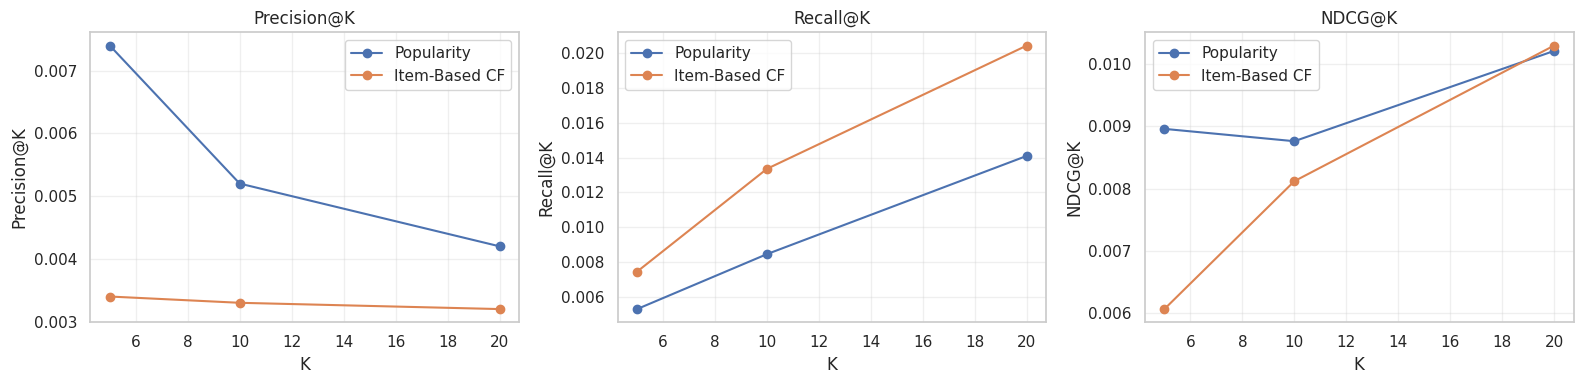

In [30]:
# ── Ranking metrics visualization ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric in zip(axes, ['Precision@K', 'Recall@K', 'NDCG@K']):
    for model in ranking_df['Model'].unique():
        subset = ranking_df[ranking_df['Model'] == model]
        ax.plot(subset['K'], subset[metric], 'o-', label=model)
    ax.set_xlabel('K')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Analysis: Similarity Distribution

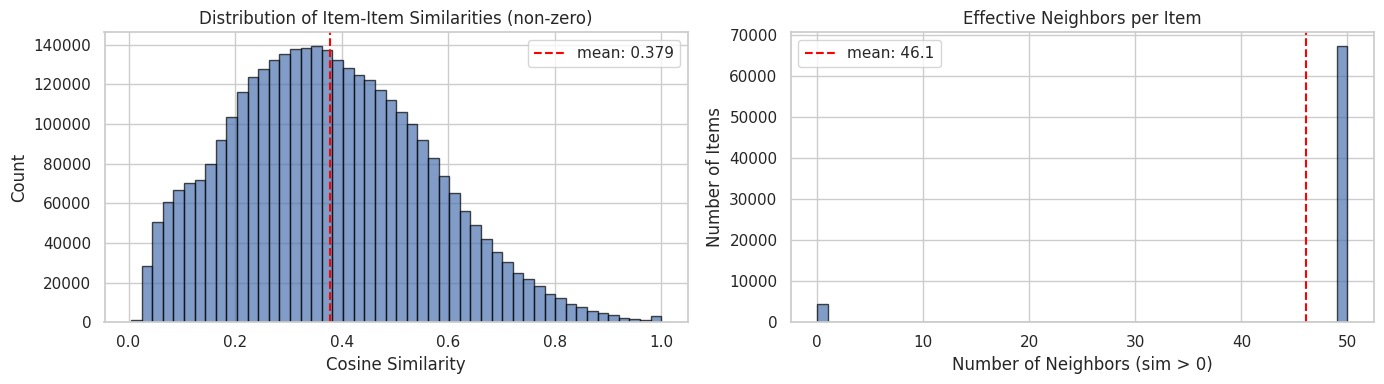

Total non-zero similarities: 3,411,131
Mean similarity: 0.3788
Items with 0 neighbors: 4,348


In [31]:
# ── Distribution of similarity scores ─────────────────────────────────
all_sims = sim_values[sim_values > 0].flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(all_sims, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Item-Item Similarities (non-zero)')
axes[0].axvline(np.mean(all_sims), color='red', linestyle='--', label=f'mean: {np.mean(all_sims):.3f}')
axes[0].legend()

# Number of effective neighbors per item
n_effective = (sim_values > 0).sum(axis=1)
axes[1].hist(n_effective, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Neighbors (sim > 0)')
axes[1].set_ylabel('Number of Items')
axes[1].set_title('Effective Neighbors per Item')
axes[1].axvline(np.mean(n_effective), color='red', linestyle='--', label=f'mean: {np.mean(n_effective):.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Total non-zero similarities: {len(all_sims):,}')
print(f'Mean similarity: {np.mean(all_sims):.4f}')
print(f'Items with 0 neighbors: {(n_effective == 0).sum():,}')

## 15. Error Analysis

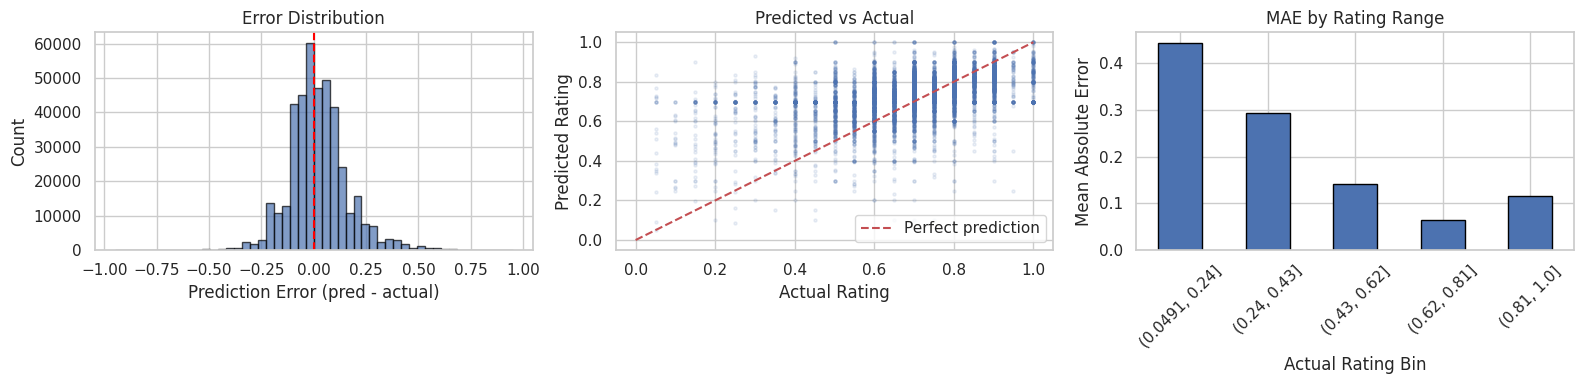

Mean error (bias): 0.0217
Error std:         0.1392


In [32]:
# ── Prediction error distribution ─────────────────────────────────────
test_df_copy = test_df.copy()
test_df_copy['itemcf_pred'] = y_test_itemcf
test_df_copy['error'] = test_df_copy['itemcf_pred'] - test_df_copy['review/overall']
test_df_copy['abs_error'] = test_df_copy['error'].abs()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Error histogram
axes[0].hist(test_df_copy['error'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Prediction Error (pred - actual)')
axes[0].set_ylabel('Count')
axes[0].set_title('Error Distribution')
axes[0].axvline(0, color='red', linestyle='--')

# Predicted vs Actual scatter (sample for visibility)
sample_idx = np.random.choice(len(test_df_copy), size=min(10000, len(test_df_copy)), replace=False)
axes[1].scatter(test_df_copy['review/overall'].values[sample_idx],
                test_df_copy['itemcf_pred'].values[sample_idx],
                alpha=0.1, s=5)
axes[1].plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].set_title('Predicted vs Actual')
axes[1].legend()

# Error by rating bucket
test_df_copy['rating_bin'] = pd.cut(test_df_copy['review/overall'], bins=5)
bin_errors = test_df_copy.groupby('rating_bin')['abs_error'].mean()
bin_errors.plot(kind='bar', ax=axes[2], edgecolor='black')
axes[2].set_xlabel('Actual Rating Bin')
axes[2].set_ylabel('Mean Absolute Error')
axes[2].set_title('MAE by Rating Range')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'Mean error (bias): {test_df_copy["error"].mean():.4f}')
print(f'Error std:         {test_df_copy["error"].std():.4f}')

## 16. Sample Recommendations

In [33]:
# ── Show recommendations for a few sample users ──────────────────────
# Pick 3 users with decent activity
user_activity = train_df.groupby('user_idx').size()
active_users = user_activity[user_activity >= 20].index.tolist()
sample_user_idxs = np.random.choice(active_users, size=min(3, len(active_users)), replace=False)

idx2user = {v: k for k, v in user2idx.items()}

# item_id → beer name lookup
item_name_lookup = train_df.drop_duplicates('item_id').set_index('item_id')['beer/name'].to_dict()

for u_idx in sample_user_idxs:
    username = idx2user.get(u_idx, '?')
    print(f'\n{"="*60}')
    print(f'User: {username} (idx={u_idx})')

    # Show their top-rated items in training
    u_train = train_df[train_df['user_idx'] == u_idx].nlargest(5, 'review/overall')
    print(f'\n  Top-rated in training:')
    for _, row in u_train.iterrows():
        print(f'    {row["beer/name"][:40]:<40s}  rating={row["review/overall"]:.2f}')

    # Show recommendations
    recs = generate_topn_itemcf(u_idx, n=10)
    print(f'\n  Item-CF Recommendations:')
    for rank, item_idx in enumerate(recs, 1):
        item_id = idx2item.get(item_idx, '?')
        beer_name = item_name_lookup.get(item_id, '?')
        print(f'    {rank:>2d}. {beer_name[:45]:<45s}  ({item_id})')


User: uglyblond1 (idx=25588)

  Top-rated in training:
    Great Divide Hibernation Ale              rating=0.85
    Capital Munich Dark                       rating=0.85
    Boulder Beer Singletrack Copper Ale       rating=0.80
    Great Divide Ridgeline Amber Ale &#40;Ar  rating=0.80
    Boulevard Bully&#033; Porter              rating=0.80

  Item-CF Recommendations:
     1. Capital Wild Rice                              (ratebeer_867)
     2. Central Waters Brewers Reserve Bourbon Barrel  (ratebeer_34746)
     3. Flying Dog Horn Dog Barley Wine                (ratebeer_689)
     4. Avery Samaels Oak-Aged Ale                     (ratebeer_48268)
     5. Stone Old Guardian &#40;Vintages 2004 and lat  (ratebeer_30838)
     6. Dogfish Head Burton Baton                      (ratebeer_39508)
     7. Kulmbacher Eisbock                             (ratebeer_14367)
     8. Lakefront Holiday Spice Lager Beer             (ratebeer_980)
     9. Great Dane Black Earth Porter                  (

## 17. Summary

### Results Overview

| Model | RMSE | MAE |
|-------|------|-----|
| Popularity (Bayesian) | 0.1212 | 0.0892 |
| User+Item Bias | 0.1308 | 0.0976 |
| **Item-Based CF (K=50)** | 0.1408 | 0.1018 |


### Key Observations

1. **Item-Based CF** leverages local item neighborhoods — items that are rated similarly by overlapping users get high cosine similarity.
2. **Sparsity impact**: With 99.96% sparsity, many item pairs have few co-rated users, which limits the quality of similarity estimates.
3. **K sensitivity**: The optimal K balances between using more signal (higher K) and diluting with dissimilar items.
4. **Comparison**: Item-Based CF should outperform the simple popularity baseline by personalizing recommendations, but may underperform matrix factorization which learns dense latent representations.
